# 01 — Data Cleaning & Exploratory Analysis
**The Mean Girls Store** (live Shopify apparel brand, Pakistan) — Feb 24 to Jul 2, 2026.

Data was extracted from the Shopify Admin API (GraphQL) and ShopifyQL analytics, then **anonymized**: customer identities are replaced with sequential `CUST-####` IDs. This notebook validates the dataset and establishes topline KPIs.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
PINK, DARK, GREY = "#e75480", "#2d2d2d", "#999999"
RAW, PROC = "../data/raw/", "../data/processed/"
orders = pd.read_csv(PROC + "orders_clean.csv", parse_dates=["created_at", "order_date", "order_month"])
valid = orders[(~orders.cancelled) & (orders.total > 500)].copy()
daily = pd.read_csv(RAW + "daily_sales.csv", parse_dates=["day"])
fmt_pkr = mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K")

In [2]:
# Topline KPIs (valid = non-cancelled, revenue > PKR 500 to exclude test/sticker-only orders)
kpi = {
    "Total orders (all)": len(orders),
    "Cancelled orders": int(orders.cancelled.sum()),
    "Valid orders": len(valid),
    "Unique customers": valid.customer.nunique(),
    "Revenue (PKR)": round(valid.total.sum()),
    "Average order value (PKR)": round(valid.total.mean()),
    "Median order value (PKR)": round(valid.total.median()),
    "Repeat customers": int((valid.groupby("customer").size() > 1).sum()),
    "Cancellation rate": f"{orders.cancelled.mean():.1%}",
}
pd.Series(kpi).to_frame("value")

,value
Total orders (all),632
Cancelled orders,24
Valid orders,602
Unique customers,531
Revenue (PKR),2531596
Average order value (PKR),4205
Median order value (PKR),3650
Repeat customers,60
Cancellation rate,3.8%


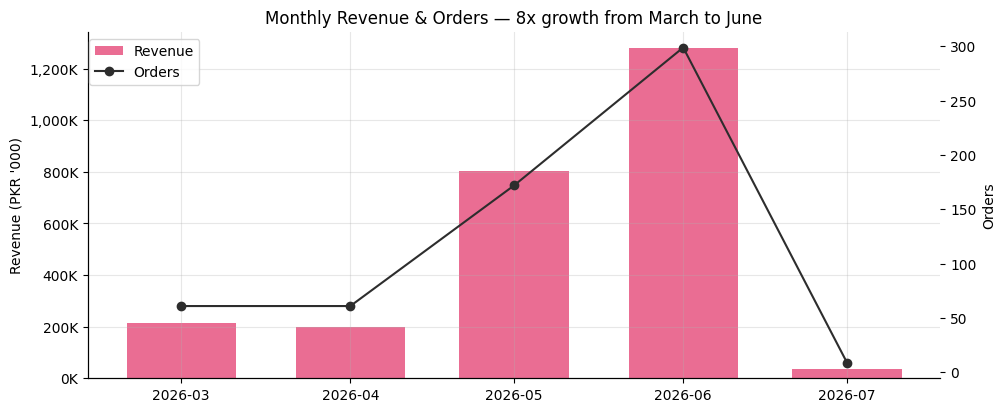

,revenue,orders,mom_growth
order_date,,,
2026-03-01,213743.15,61,—
2026-04-01,199405.60,61,-7%
2026-05-01,802432.34,172,+302%
2026-06-01,1278797.11,299,+59%
2026-07-01,37218.12,9,-97%


In [3]:
# Monthly revenue and orders
m = valid.set_index("order_date").resample("MS").agg(revenue=("total","sum"), orders=("order","count"))
fig, ax1 = plt.subplots()
ax1.bar(m.index, m.revenue, width=20, color=PINK, alpha=.85, label="Revenue")
ax1.yaxis.set_major_formatter(fmt_pkr); ax1.set_ylabel("Revenue (PKR '000)")
ax2 = ax1.twinx(); ax2.plot(m.index, m.orders, "o-", color=DARK, label="Orders"); ax2.set_ylabel("Orders"); ax2.grid(False)
ax1.set_title("Monthly Revenue & Orders — 8x growth from March to June")
fig.legend(loc="upper left", bbox_to_anchor=(.12,.88)); plt.show()
m.assign(mom_growth=m.revenue.pct_change().map(lambda v: f"{v:+.0%}" if pd.notna(v) else "—"))

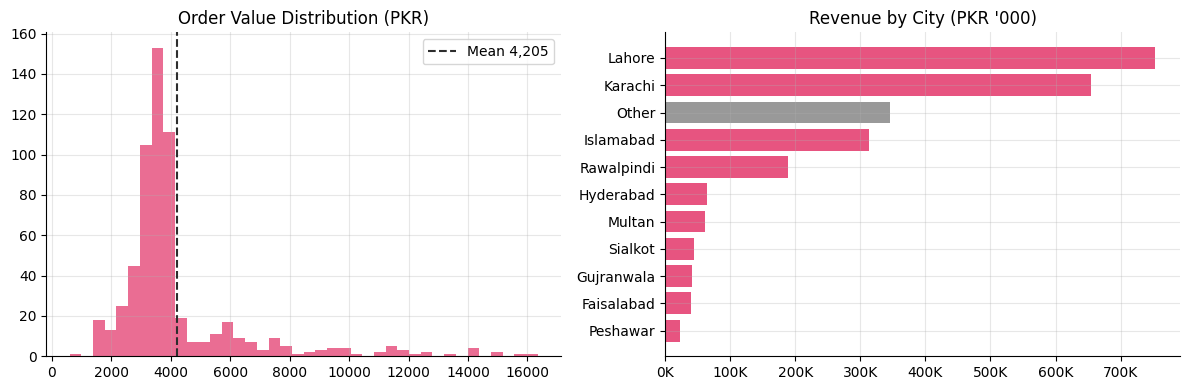

Top 3 cities = 69% of revenue


In [4]:
# Order value distribution + geography
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valid.total, bins=40, color=PINK, alpha=.85)
axes[0].axvline(valid.total.mean(), color=DARK, ls="--", label=f"Mean {valid.total.mean():,.0f}")
axes[0].set_title("Order Value Distribution (PKR)"); axes[0].legend()
city = valid.groupby("city_group").total.sum().sort_values()
axes[1].barh(city.index, city.values, color=[PINK if c!="Other" else GREY for c in city.index])
axes[1].xaxis.set_major_formatter(fmt_pkr); axes[1].set_title("Revenue by City (PKR '000)")
plt.tight_layout(); plt.show()
print(f"Top 3 cities = {city.sort_values(ascending=False).head(3).sum()/city.sum():.0%} of revenue")

### Findings
- Revenue grew from **PKR 204K (Mar)** to **PKR 1.23M (Jun)** — a 6x jump in 3 months, driven mainly by order volume (63 → 308 orders), not price increases.
- AOV is ~**PKR 4,200** with a long right tail: a wholesale-style spike on May 21 (10+ orders of PKR 11K–16K) inflates May.
- **Karachi + Lahore + Islamabad/Rawalpindi ≈ 70%+ of revenue** — a concentrated, urban, Gen-Z customer base.
- Cancellation rate ~3.8%, typical for COD-heavy Pakistani e-commerce.